# Importing Libraries

In [126]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Fetching

In [127]:
features = ['pm2_5', 'pm10', 'carbon_monoxide', 'carbon_dioxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust', 'uv_index']
weather_features = ['temperature_2m','relative_humidity_2m','wind_speed_10m','wind_direction_10m', 'cloud_cover'
]
latitude, longitude = 24.8607, 67.0011

In [ ]:
end_date = datetime.now().date() - timedelta(days=1)
start_date = end_date - timedelta(days=365)

params = {
    'latitude': latitude,
    'longitude': longitude,
    'start_date': start_date.strftime('%Y-%m-%d'),
    'end_date': end_date.strftime('%Y-%m-%d'),
    'hourly': ','.join(features + ['us_aqi']),
    'timezone': 'Asia/Karachi'
}

url = 'https://air-quality-api.open-meteo.com/v1/air-quality'

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

# Create dataframe from hourly data
df = pd.DataFrame({
    'datetime': pd.date_range(start=data['hourly']['time'][0], periods=len(data['hourly']['pm10']), freq='h'),
    'pm10': data['hourly']['pm10'],
    'pm2_5': data['hourly']['pm2_5'],
    'carbon_monoxide': data['hourly']['carbon_monoxide'],
    'carbon_dioxide': data['hourly']['carbon_dioxide'],
    'nitrogen_dioxide': data['hourly']['nitrogen_dioxide'],
    'sulphur_dioxide': data['hourly']['sulphur_dioxide'],
    'ozone': data['hourly']['ozone'],
    'dust': data['hourly']['dust'],
    'uv_index': data['hourly']['uv_index'],
    'us_aqi': data['hourly']['us_aqi']
})

print(f"\nAir Quality DataFrame shape: {df.shape}")
print(f"\nAir Quality data sample:")
print(df.head())

In [ ]:
end_date = datetime.now().date() - timedelta(days=1)
start_date = end_date - timedelta(days=365)

weather_params = {
    'latitude': latitude,
    'longitude': longitude,
    'start_date': start_date.strftime('%Y-%m-%d'),
    'end_date': end_date.strftime('%Y-%m-%d'),
    'hourly': ','.join(weather_features),
    'timezone': 'Asia/Karachi'
}

weather_url = 'https://archive-api.open-meteo.com/v1/archive'

response = requests.get(weather_url, params=weather_params)
response.raise_for_status()

weather_data = response.json()

weather_df = pd.DataFrame({
    'datetime': pd.date_range(
        start=weather_data['hourly']['time'][0],
        periods=len(weather_data['hourly']['temperature_2m']),
        freq='h'
    ),
    'temperature_2m': weather_data['hourly']['temperature_2m'],
    'relative_humidity_2m': weather_data['hourly']['relative_humidity_2m'],
    'wind_speed_10m': weather_data['hourly']['wind_speed_10m'],
    'wind_direction_10m': weather_data['hourly']['wind_direction_10m'],
    'cloud_cover': weather_data['hourly']['cloud_cover'],
})

print(f"\nWeather DataFrame shape: {weather_df.shape}")
print(f"\nWeather data sample:")
print(weather_df.head(10))

# Merge weather data with air quality data on datetime
print("\n----")
print("MERGE WEATHER AND AIR QUALITY DATA")
print("----")

df['datetime'] = pd.to_datetime(df['datetime'])
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])

df_combined = pd.merge(df, weather_df, on='datetime', how='inner')

print(f"\nCombined DataFrame shape: {df_combined.shape}")
print(f"Air quality rows: {df.shape[0]}")
print(f"Weather rows: {weather_df.shape[0]}")
print(f"Merged rows: {df_combined.shape[0]}")

print(f"\nColumns in combined DataFrame: {len(df_combined.columns)}")
print(f"Combined DataFrame columns:")
for i, col in enumerate(df_combined.columns, 1):
    print(f"{i}. {col}")

print(f"\nCombined data sample:")
print(df_combined.head(10))


df = df_combined

df.to_csv("raw_features.csv", index=False)
print(f"Shape: {df.shape}")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())

# 2. Raw Data

In [130]:
feature_cols = features + weather_features
target_col = 'us_aqi'

In [131]:
df = pd.read_csv('raw_features.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

keep_cols = ['datetime'] + [target_col] + [c for c in feature_cols if c in df.columns]
df = df[keep_cols].copy()

## 2.1. Data Summary

This is a dataset containing the hourly record of air quality and weather metrics for Karachi City. 

It consist of data from the last year, beginning on May 24, 2025 and ending on May 24, 2026. 

The dataset consists of 8,784 observations (rows) and 16 variables (columns).

## 2.2. Column Description

`datetime`: The date and time of the recorded observation.

`pm10`: Particulate Matter 10. Refers to inhalable particles with diameters that are generally 10 micrometers and smaller.

`pm2_5`: Fine Particulate Matter 2.5. Refers to fine inhalable particles with diameters that are generally 2.5 micrometers and smaller.

`carbon_monoxide (CO)`: A colorless, odorless gas produced by the incomplete combustion of fossil fuels, primarily from vehicles and machinery.

`carbon_dioxide (CO2)`: A greenhouse gas produced by human activities (like burning fossil fuels) and natural processes (like respiration).

`nitrogen_dioxide (NO2)`: A highly reactive gas primarily emitted from the burning of fuel (e.g., from cars, trucks, and power plants). It contributes to the formation of smog and acid rain.

`sulphur_dioxide (SO2)`: A toxic gas emitted largely by fossil fuel combustion at power plants and other industrial facilities.

`ozone (O3)`: Ground-level ozone. Ground-level ozone is a harmful air pollutant created by chemical reactions between NO₂ and volatile organic compounds (VOCs) in the presence of sunlight (smog).

`dust`: The concentration of airborne dust particles, which can be influenced by wind, soil erosion, and human activities.

`us_aqi`: The United States Air Quality Index. A standardized composite metric used to report overall air quality. It ranges from 0 to 500, with higher values indicating a greater level of air pollution and higher health risks.

# 3. Data Preprocessing

## 3.1. Assessment

In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              8784 non-null   datetime64[us]
 1   us_aqi                8784 non-null   int64         
 2   pm2_5                 8784 non-null   float64       
 3   pm10                  8784 non-null   float64       
 4   carbon_monoxide       8784 non-null   float64       
 5   carbon_dioxide        8784 non-null   int64         
 6   nitrogen_dioxide      8784 non-null   float64       
 7   sulphur_dioxide       8784 non-null   float64       
 8   ozone                 8784 non-null   float64       
 9   dust                  8784 non-null   float64       
 10  uv_index              8784 non-null   float64       
 11  temperature_2m        8784 non-null   float64       
 12  relative_humidity_2m  8784 non-null   int64         
 13  wind_speed_10m        8784 no

In [133]:
df.describe()

,datetime,us_aqi,pm2_5,pm10,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,uv_index,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,cloud_cover
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,2025-11-24 23:30:00,89.151867,29.654747,56.769171,540.366234,454.858493,21.418135,15.913388,71.672587,47.353711,1.597148,26.361077,65.793716,10.696585,215.178962,35.612933
min,2025-05-26 00:00:00,32.000000,3.500000,3.700000,74.000000,439.000000,0.000000,3.200000,0.000000,0.000000,0.000000,9.200000,7.000000,0.200000,1.000000,0.000000
25%,2025-08-25 11:45:00,73.000000,21.100000,36.100000,250.000000,445.000000,7.600000,10.400000,43.000000,11.000000,0.000000,23.500000,51.000000,7.400000,200.750000,0.000000
50%,2025-11-24 23:30:00,84.000000,26.700000,49.200000,369.000000,451.000000,14.700000,13.800000,63.000000,34.000000,0.000000,27.300000,70.000000,10.400000,245.000000,14.000000
75%,2026-02-24 11:15:00,101.000000,35.300000,68.500000,670.250000,459.000000,28.600000,19.100000,96.000000,65.000000,2.600000,29.500000,83.000000,13.800000,269.000000,84.000000
max,2026-05-26 23:00:00,165.000000,96.400000,504.800000,4515.000000,533.000000,138.500000,65.400000,203.000000,597.000000,11.700000,41.200000,100.000000,26.800000,360.000000,100.000000
std,NaN,22.943146,12.721733,34.278047,455.317312,13.291618,19.517950,8.459896,40.470421,54.900595,2.523574,4.683639,21.025427,4.452019,93.284957,40.825112


## 3.2. Completeness

In [134]:
print("Missing Values Before Preprocessing:")
print(df.isnull().sum().sum())

# Handle missing values: Forward-fill for short gaps (1-2 hours), then linear interpolation for longer gaps
df[feature_cols + [target_col]] = df[feature_cols + [target_col]].ffill(limit=2)
df[feature_cols + [target_col]] = df[feature_cols + [target_col]].interpolate(method='linear', limit_direction='both')

df[feature_cols + [target_col]] = df[feature_cols + [target_col]].bfill().ffill()

Missing Values Before Preprocessing:
0


In [135]:
print("Missing Values After Preprocessing:")
print(df.isnull().sum().sum())
print()

print("Data shape:", df.shape)
print(df.head())
print(df.sample(5))

Missing Values After Preprocessing:
0

Data shape: (8784, 16)
             datetime  us_aqi  pm2_5  pm10  carbon_monoxide  carbon_dioxide  \
0 2025-05-26 00:00:00      83   30.6  63.1            190.0             448   
1 2025-05-26 01:00:00      84   29.1  59.5            166.0             447   
2 2025-05-26 02:00:00      84   27.7  56.3            149.0             447   
3 2025-05-26 03:00:00      85   26.4  53.4            137.0             448   
4 2025-05-26 04:00:00      85   25.0  50.1            132.0             448   

   nitrogen_dioxide  sulphur_dioxide  ozone  dust  uv_index  temperature_2m  \
0              13.7             11.3   47.0  56.0       0.0            29.2   
1              11.3             10.0   50.0  51.0       0.0            29.1   
2               9.2              8.8   52.0  47.0       0.0            29.0   
3               7.5              7.9   54.0  43.0       0.0            29.0   
4               6.1              7.2   55.0  40.0       0.0         

# 4. Exploratory Data Analysis

## 4.1. Univariate Analysis

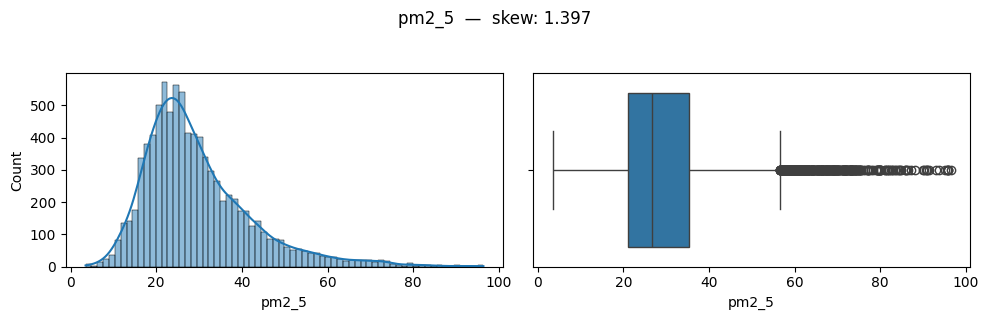

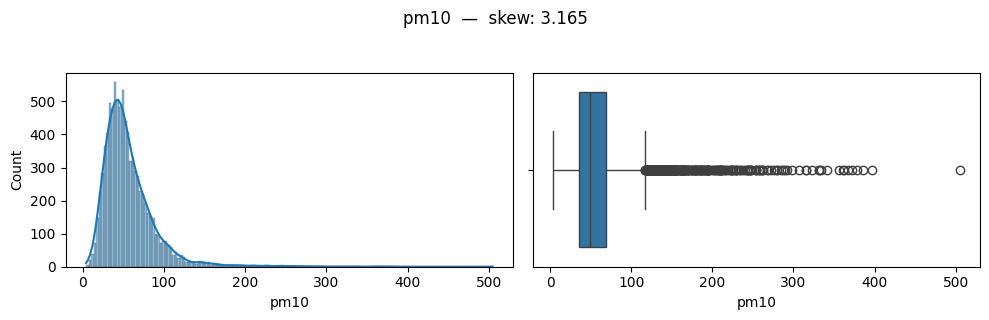

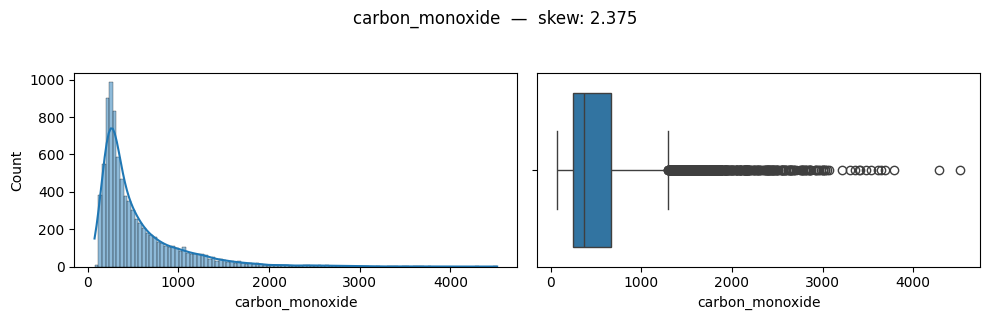

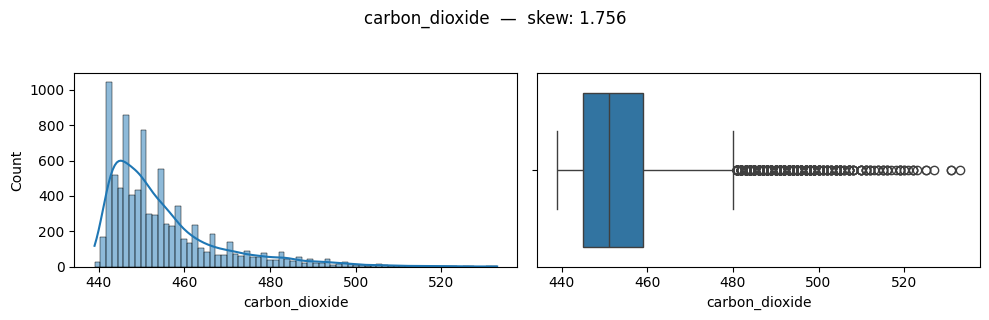

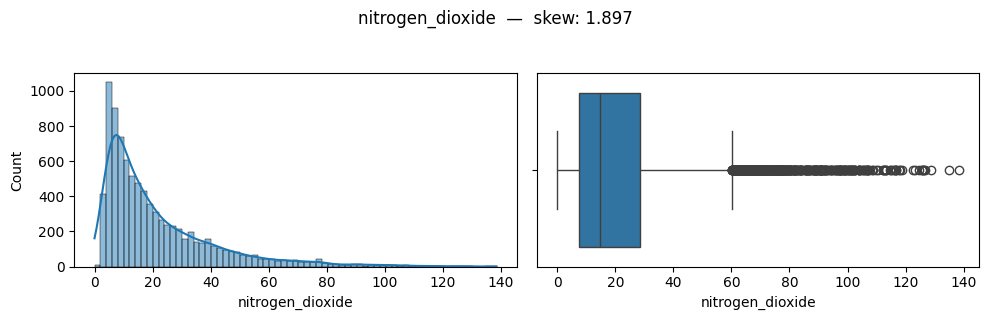

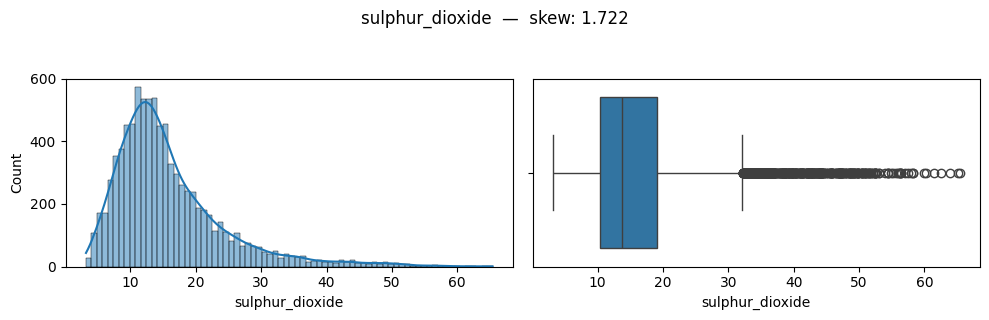

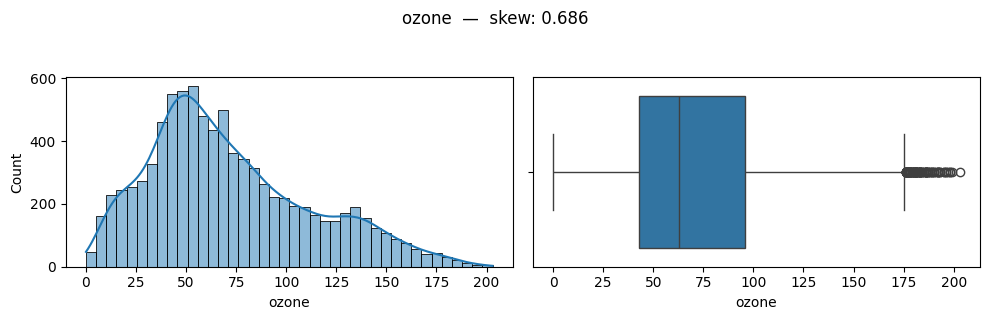

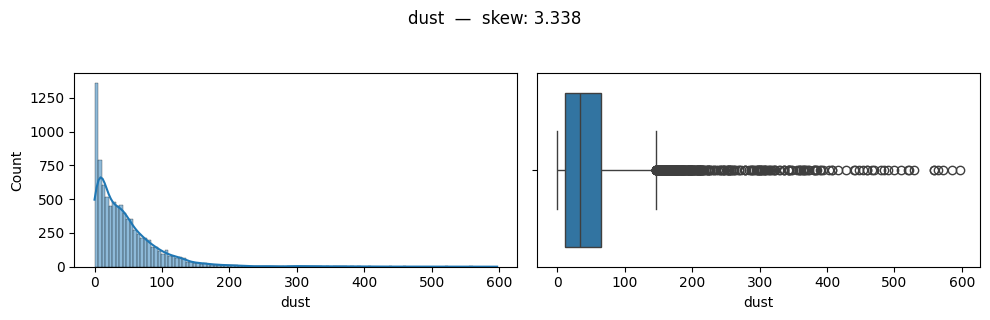

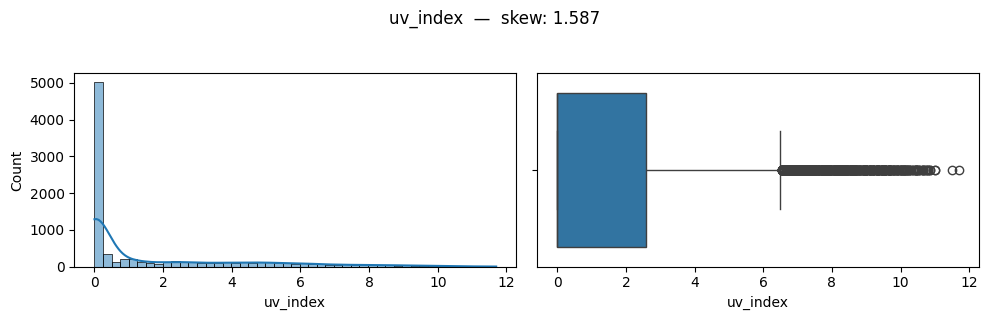

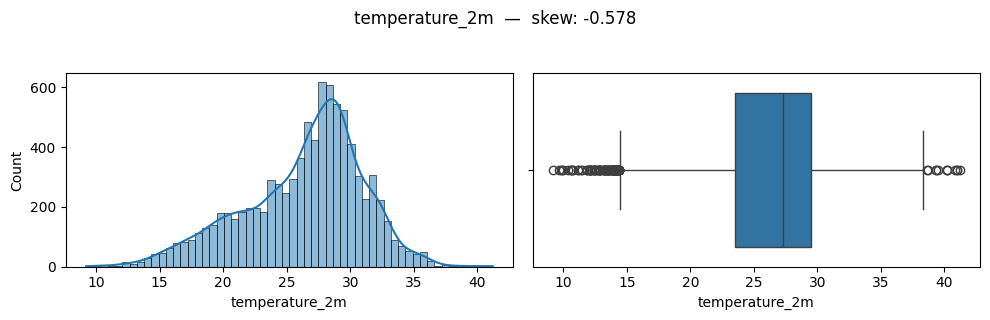

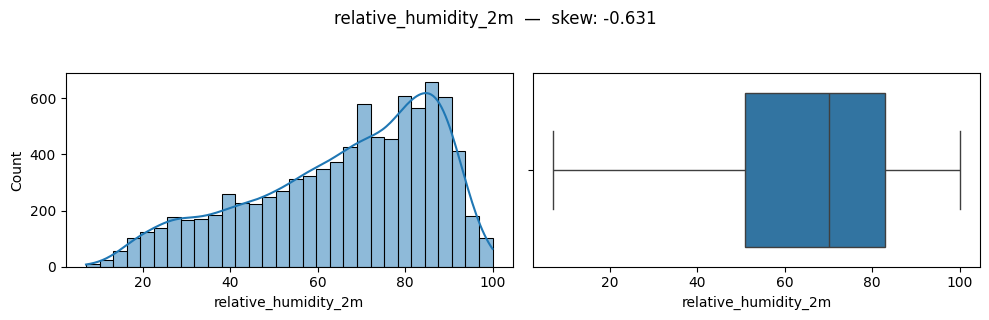

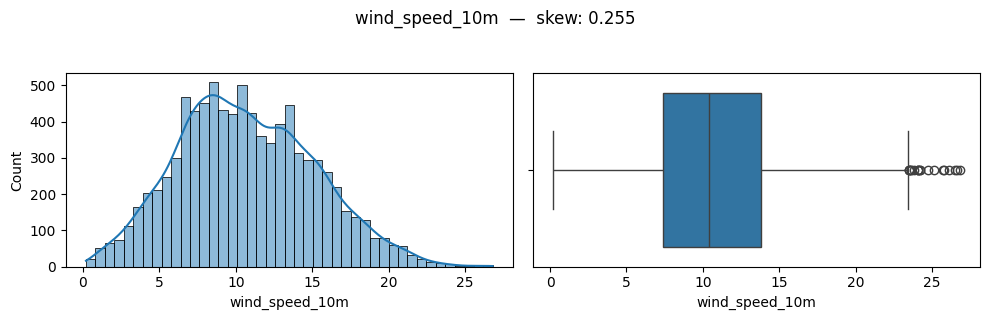

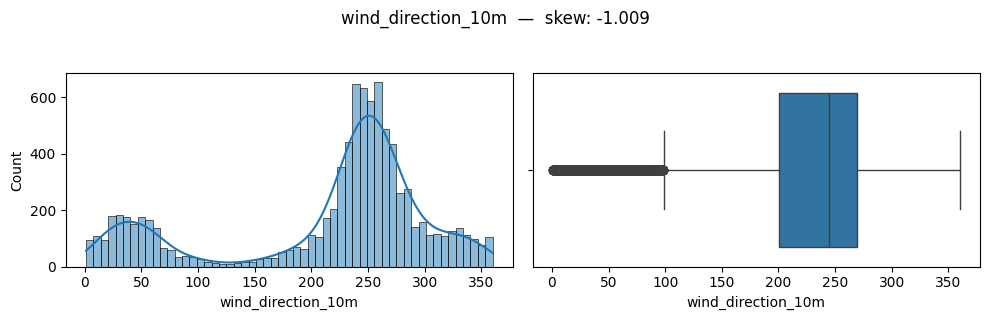

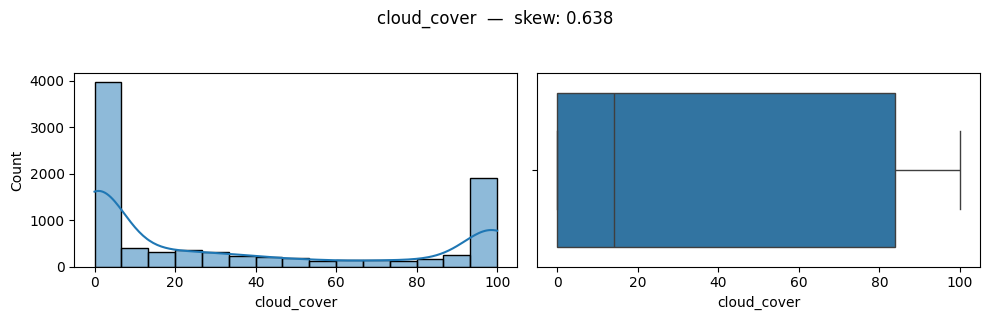

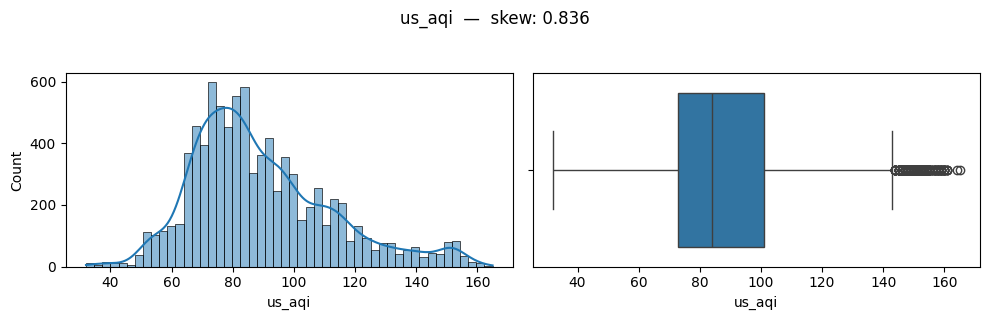

In [136]:
cols = list(dict.fromkeys(feature_cols + [target_col]))

for col in cols:
    if col not in df.columns:
        continue
    ser = pd.to_numeric(df[col], errors='coerce').dropna()
    skew_val = ser.skew()
    plt.figure(figsize=(10,3))
    plt.suptitle(f"{col}  —  skew: {skew_val:.3f}", y=1.05)
    plt.subplot(1,2,1)
    sns.histplot(ser, kde=True)
    plt.xlabel(col)
    plt.subplot(1,2,2)
    sns.boxplot(x=ser)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### IQR Outlier Handling

In [137]:
for col in feature_cols:
    if col in ['wind_direction_10m', 'cloud_cover', 'relative_humidity_2m']:
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower_bound, upper_bound)

In [138]:
print("After IQR:")
print(df[feature_cols].describe())

After IQR:
             pm2_5         pm10  carbon_monoxide  carbon_dioxide  \
count  8784.000000  8784.000000      8784.000000     8784.000000   
mean     29.182297    54.571209       505.903134      454.112819   
std      11.294314    25.323258       344.428797       11.111327   
min       3.500000     3.700000        74.000000      439.000000   
25%      21.100000    36.100000       250.000000      445.000000   
50%      26.700000    49.200000       369.000000      451.000000   
75%      35.300000    68.500000       670.250000      459.000000   
max      56.600000   117.100000      1300.625000      480.000000   

       nitrogen_dioxide  sulphur_dioxide        ozone         dust  \
count       8784.000000      8784.000000  8784.000000  8784.000000   
mean          20.367748        15.447530    71.584813    43.757741   
std           16.264598         7.040079    40.229984    39.851675   
min            0.000000         3.200000     0.000000     0.000000   
25%            7.600000   

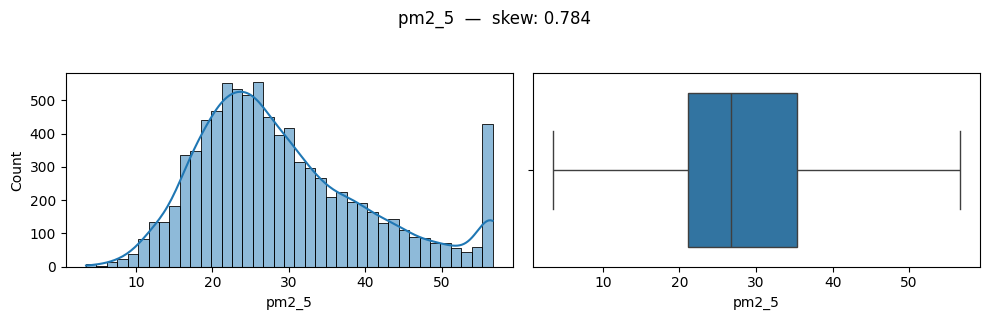

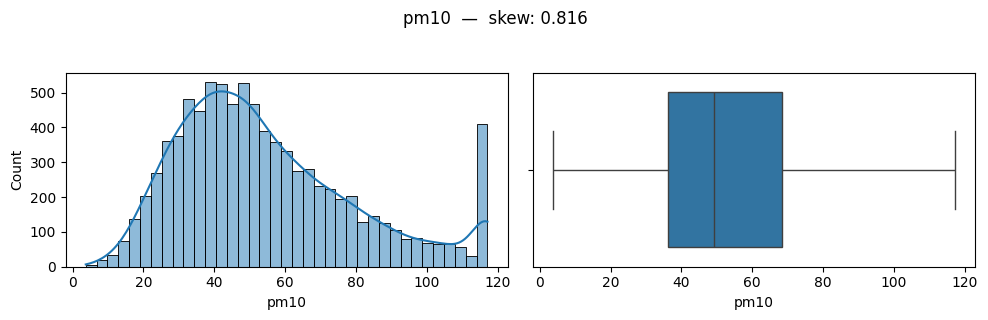

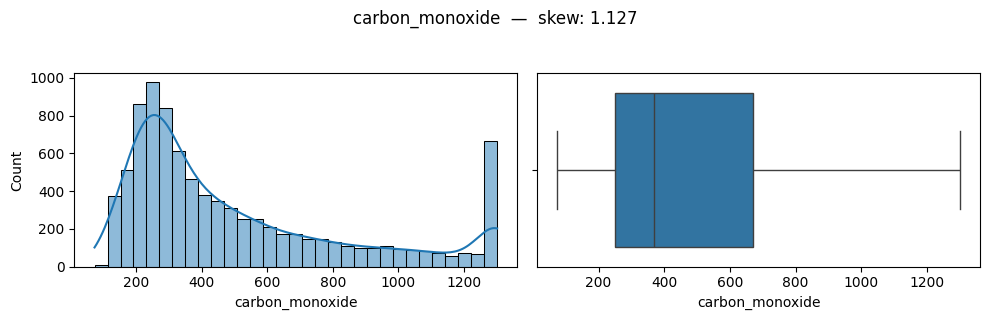

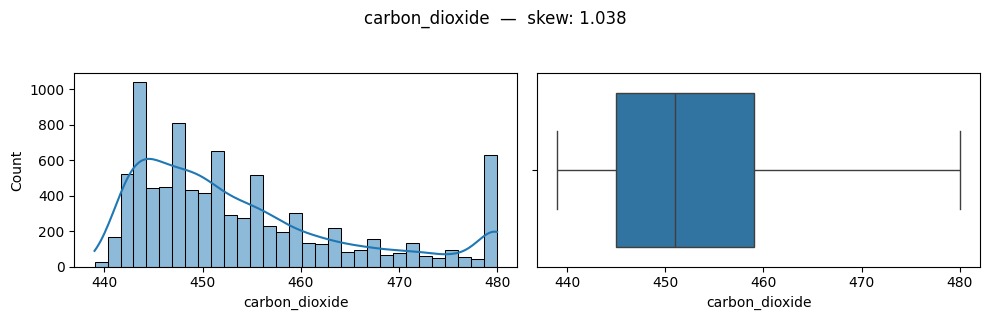

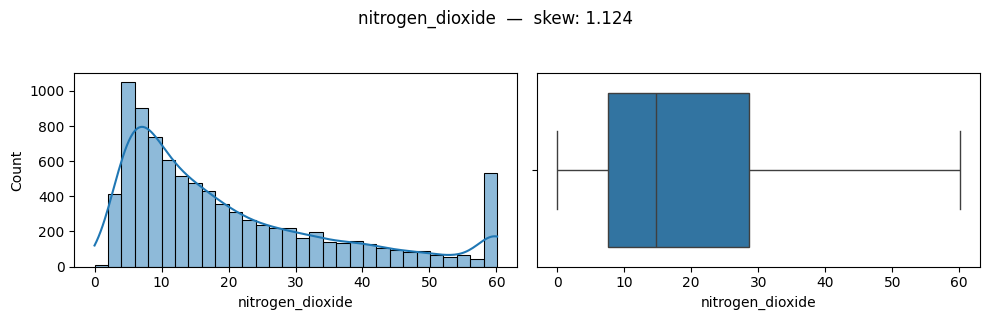

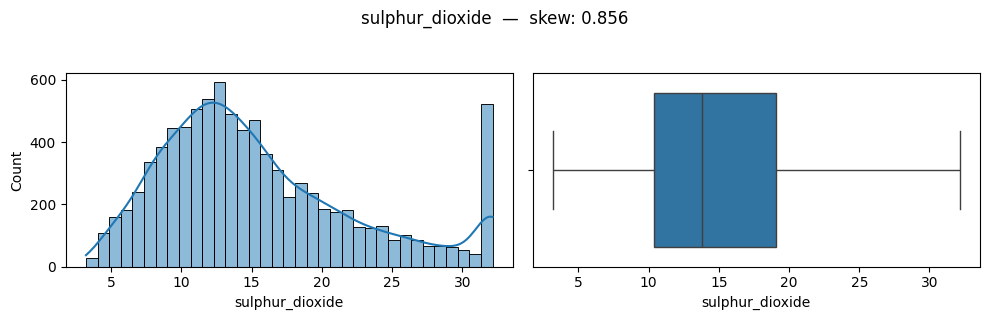

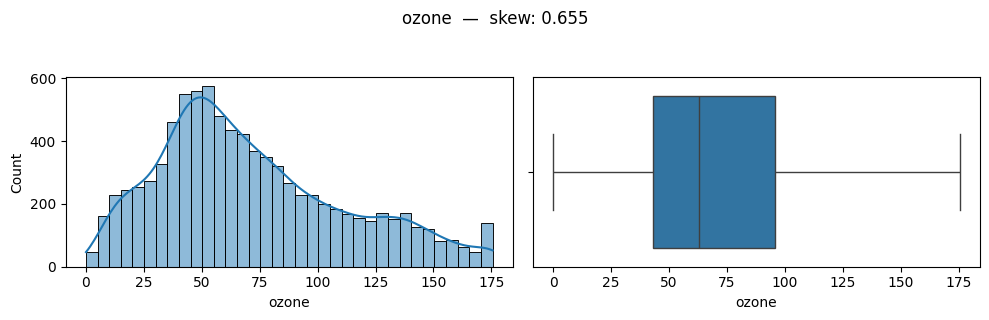

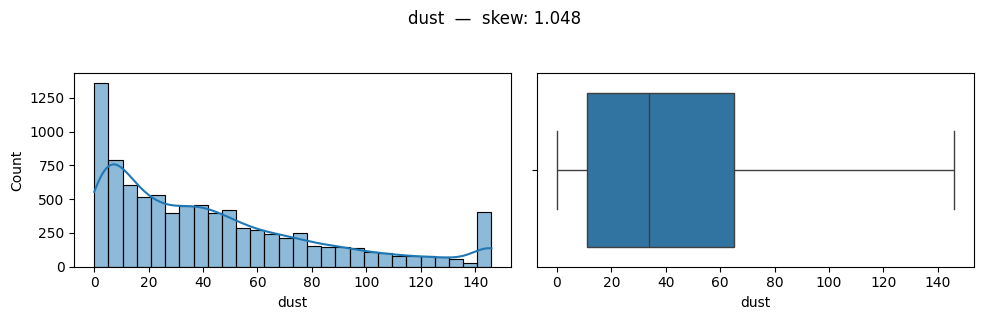

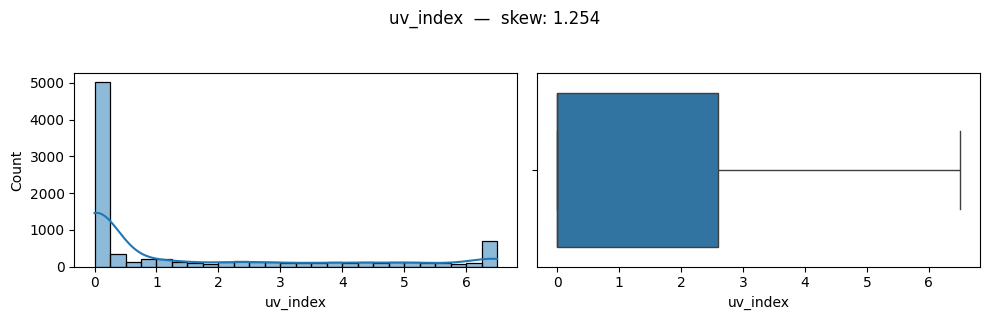

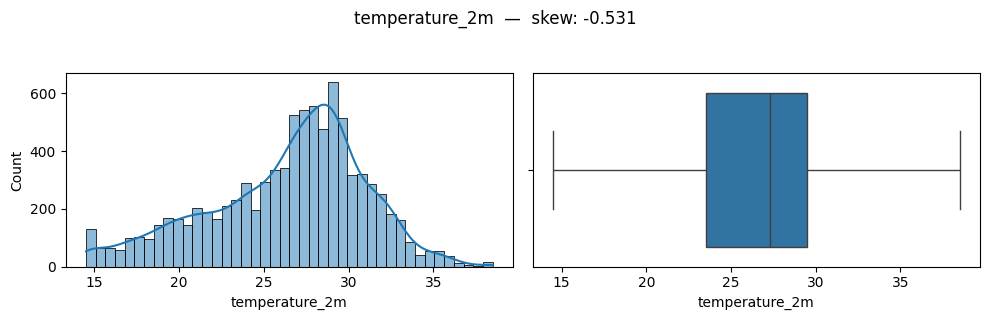

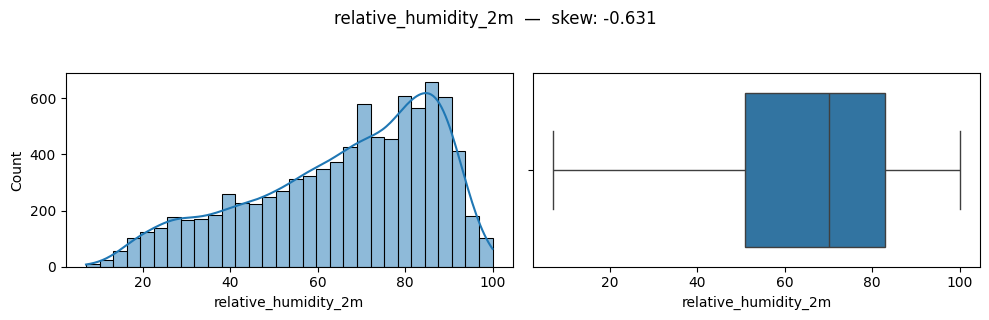

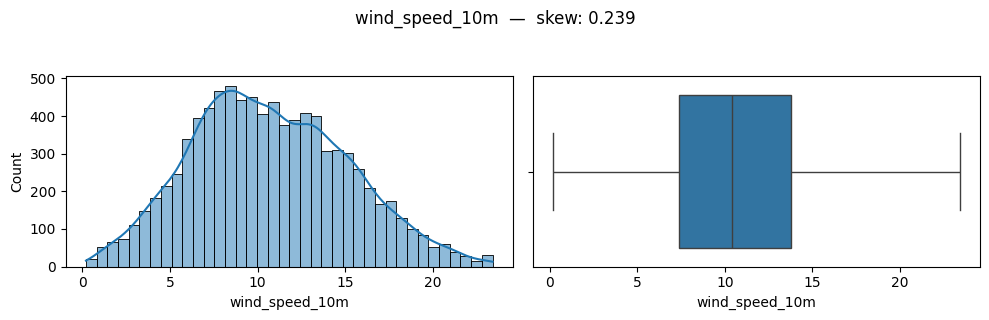

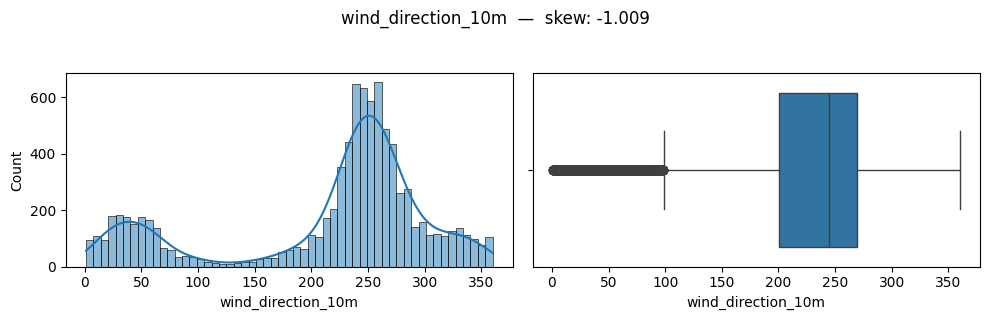

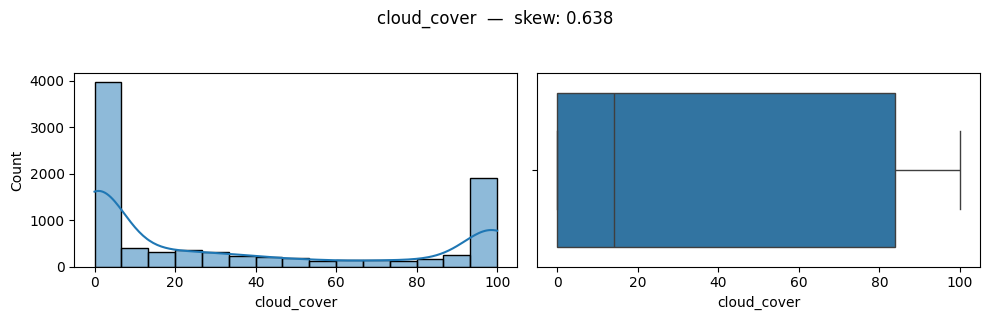

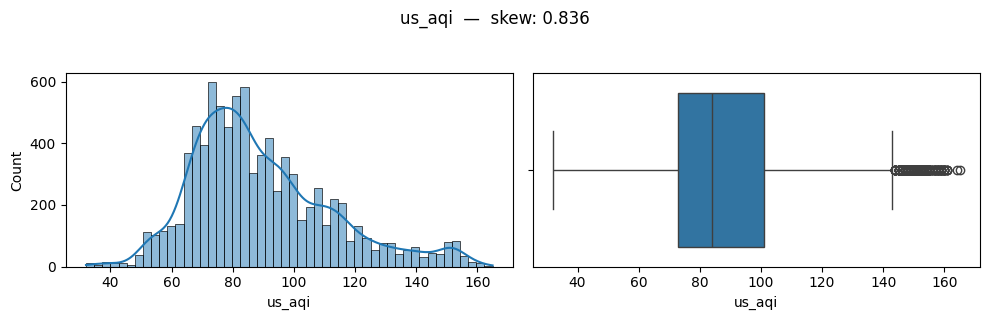

In [139]:
cols = list(dict.fromkeys(feature_cols + [target_col]))

for col in cols:
    if col not in df.columns:
        continue
    ser = pd.to_numeric(df[col], errors='coerce').dropna()
    skew_val = ser.skew()
    plt.figure(figsize=(10,3))
    plt.suptitle(f"{col}  —  skew: {skew_val:.3f}", y=1.05)
    plt.subplot(1,2,1)
    sns.histplot(ser, kde=True)
    plt.xlabel(col)
    plt.subplot(1,2,2)
    sns.boxplot(x=ser)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## 4.2. Feature Engineering

### Time-Based Features

In [140]:
df['hour'] = pd.to_datetime(df['datetime']).dt.hour
df['day_of_week'] = pd.to_datetime(df['datetime']).dt.dayofweek
df['month'] = pd.to_datetime(df['datetime']).dt.month

for c in ['hour', 'day_of_week', 'month']:
    if c not in feature_cols:
        feature_cols.append(c)

In [141]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df = df.drop(['hour', 'day_of_week', 'month'], axis=1)

try:
    feature_cols.remove('hour')
    feature_cols.remove('day_of_week')
    feature_cols.remove('month')
except ValueError:
    pass

feature_cols += ['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']

### Wind Components

In [142]:
rad = np.deg2rad(df['wind_direction_10m'])
df['wind_u'] = -df['wind_speed_10m'] * np.sin(rad)  # east-west component
df['wind_v'] = -df['wind_speed_10m'] * np.cos(rad)  # north-south component

if 'wind_direction_10m' in df.columns:
    df.drop(columns=['wind_direction_10m'], inplace=True)

if 'wind_direction_10m' in feature_cols:
    feature_cols.remove('wind_direction_10m')

feature_cols += ['wind_u', 'wind_v']

### Rolling Means and Standard Deviations

In [143]:
rolling_mean_windows = [36]  # hours
rolling_std_windows = [72]  # hours
rolling_variables = ['pm2_5', 'carbon_monoxide', 'pm10']

# 1. ROLLING MEANS
for window in rolling_mean_windows:
    for var in rolling_variables:
        df[f'{var}_rolling_mean_{window}h'] = df[var].shift(1).rolling(window=window).mean()

# 2. ROLLING STANDARD DEVIATIONS
for window in rolling_std_windows:
    for var in rolling_variables:
        if var == 'carbon_monoxide':
            continue
        df[f'{var}_rolling_std_{window}h'] = df[var].shift(1).rolling(window=window).std()

print("\nRolling Mean and std Features Created")

# Add rolling mean features to feature_cols
rolling_features = []
for window in rolling_mean_windows + rolling_std_windows:
    for var in rolling_variables:
        col_name = f'{var}_rolling_mean_{window}h'
        std_name = f'{var}_rolling_std_{window}h'
        if col_name not in feature_cols:
            feature_cols.append(col_name)
        if std_name not in feature_cols:
            feature_cols.append(std_name)
            
        rolling_features.append(std_name)
        rolling_features.append(col_name)

# Handle NaN values from rolling operations
df = df.ffill()


Rolling Mean and std Features Created


### Derived Features

In [144]:
df['aqi_change_rate'] = df["us_aqi"].diff()

df["pm_ratio"] = np.where(df["pm10"] > 0, df["pm2_5"] / df["pm10"], 0)

hour = pd.to_datetime(df['datetime']).dt.hour
df['is_rush_hour'] = (((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 19))).astype(int)

dow = pd.to_datetime(df['datetime']).dt.dayofweek
df['is_workday'] = ((dow >= 0) & (dow <= 4)).astype(int)


df['precip_likelihood'] = df['relative_humidity_2m'] * df['cloud_cover']


for var in ['is_rush_hour', 'is_workday', "pm_ratio", 'precip_likelihood', 'aqi_change_rate']:
    if  var not in feature_cols:
        feature_cols.append(var)


## 4.3. Multivariate Analysis

In [145]:
cols_all = [c for c in feature_cols if c in df.columns] + [target_col]
corr_all = df[cols_all].corr(method='pearson')

# Correlation table between target and each feature
corr_target = corr_all[target_col]
corr_target_df = corr_target.reset_index().rename(columns={'index':'feature', 'us_aqi':'pearson_r'})
corr_target_df['abs_r'] = corr_target_df['pearson_r'].abs()
corr_target_df = corr_target_df.sort_values('abs_r', ascending=False).reset_index(drop=True)

print("Pearson correlation between target and features:")
print(corr_target_df[['feature','pearson_r']])

Pearson correlation between target and features:
                             feature  pearson_r
0                             us_aqi   1.000000
1             pm2_5_rolling_mean_36h   0.921188
2                              pm2_5   0.702545
3   carbon_monoxide_rolling_mean_36h   0.628649
4              pm2_5_rolling_std_72h   0.532882
5                     carbon_dioxide   0.488697
6                    carbon_monoxide   0.487937
7                    sulphur_dioxide   0.457703
8                          month_cos   0.454376
9              pm10_rolling_mean_36h   0.393563
10                    wind_speed_10m  -0.368941
11                            wind_u  -0.368396
12                  nitrogen_dioxide   0.367791
13                          pm_ratio   0.347117
14              relative_humidity_2m  -0.332431
15                 precip_likelihood  -0.321041
16                       cloud_cover  -0.301130
17                              pm10   0.283617
18                    temperature_2m  -

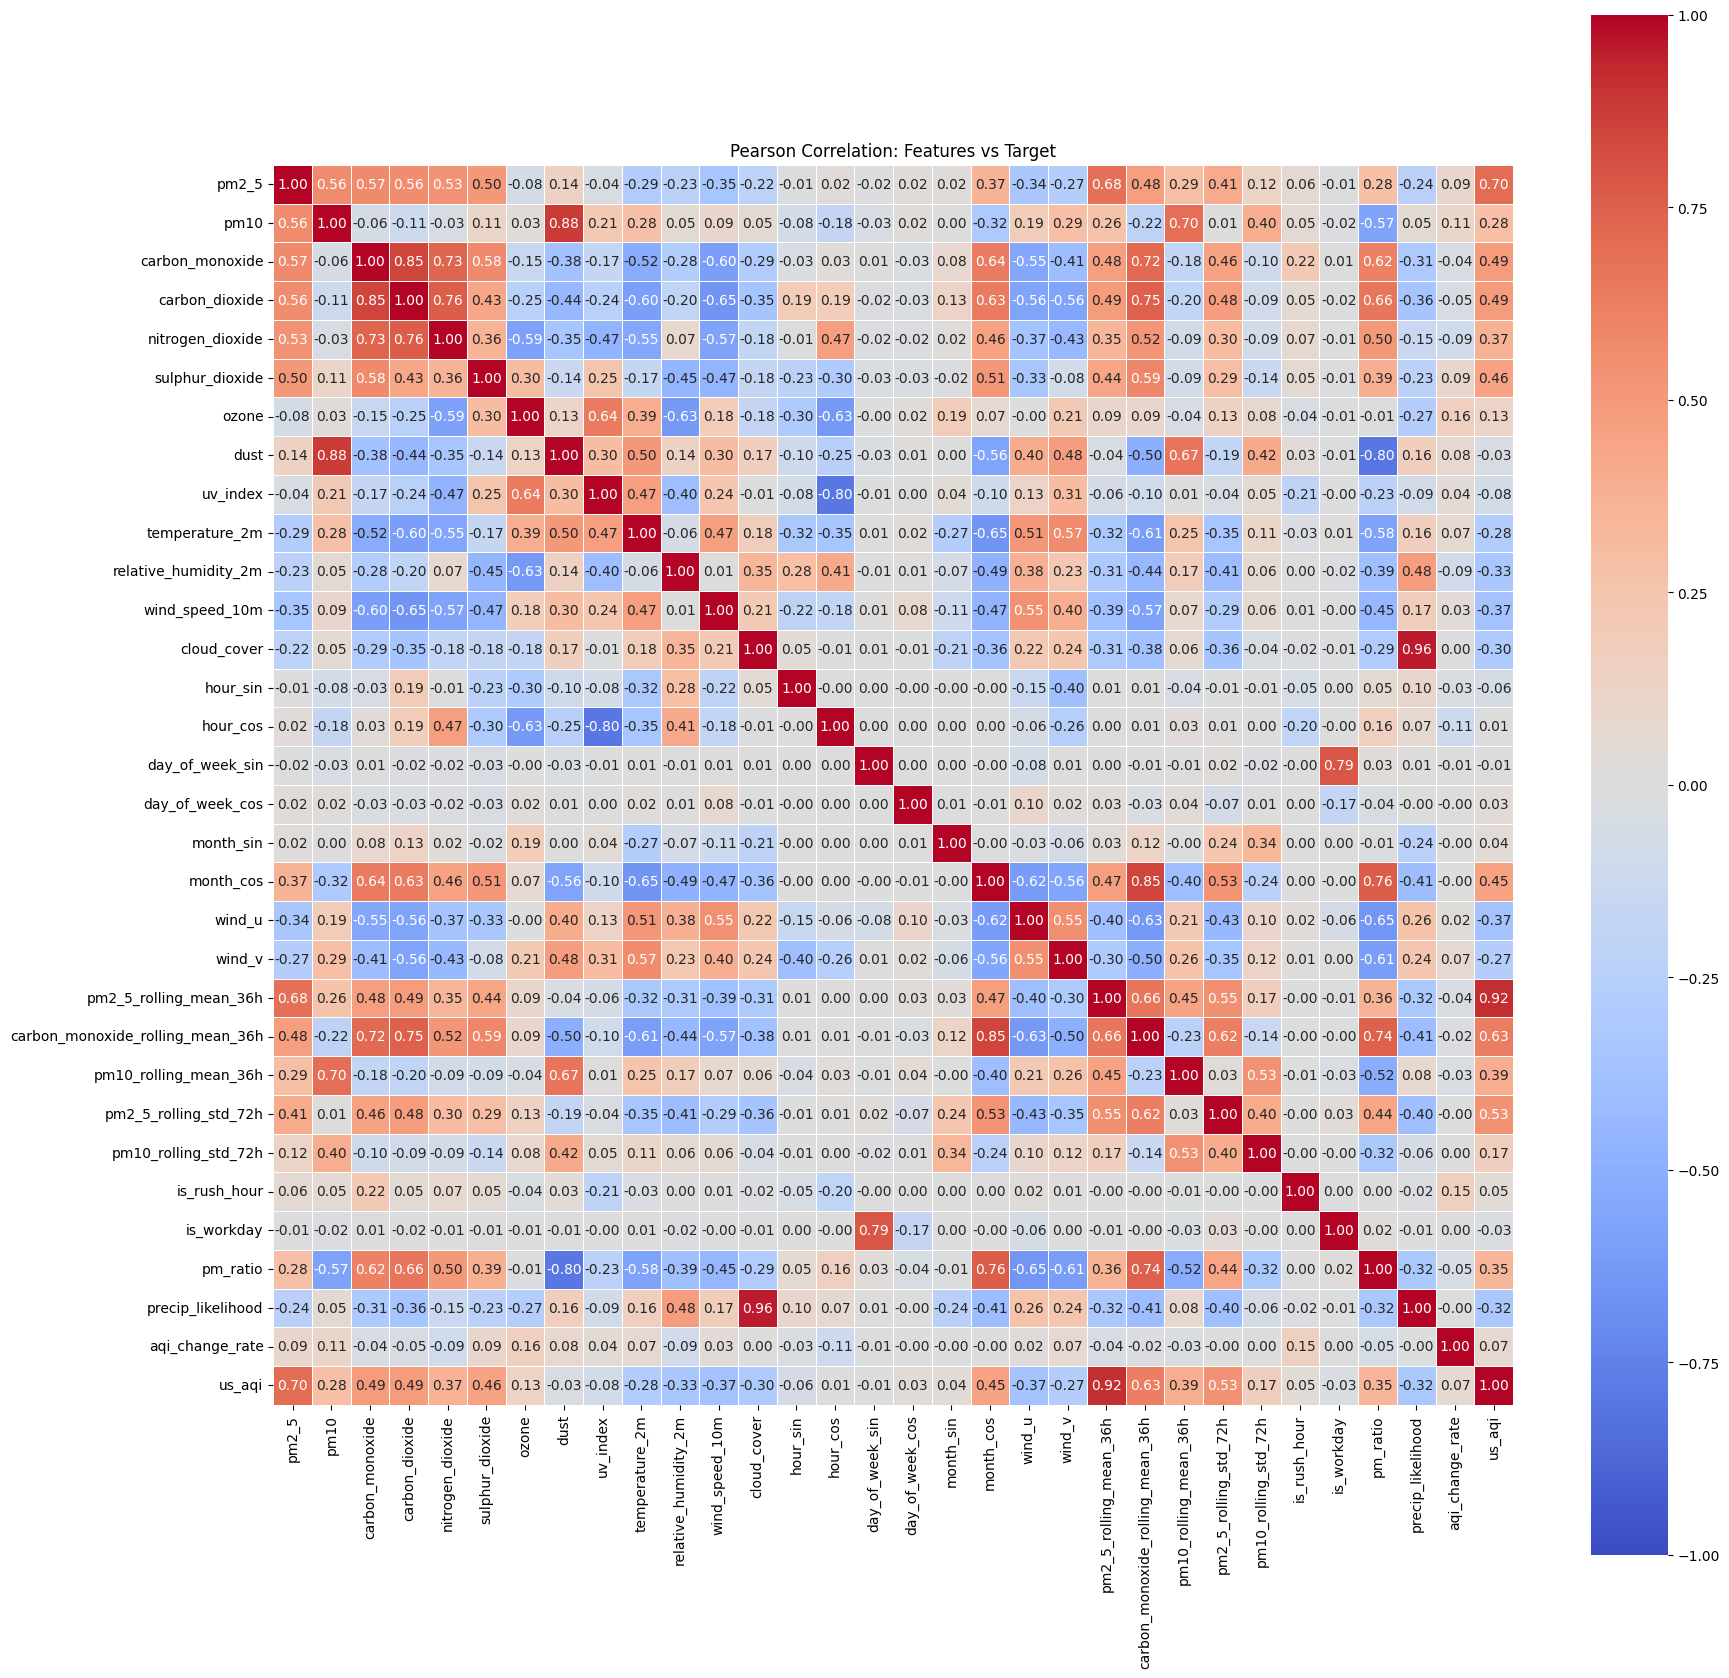

In [146]:
plt.figure(figsize=(20,20))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Pearson Correlation: Features vs Target")
plt.show()

### Drop Low Target Correlation Features (correlation < 0.05)

In [147]:
low_corr_features = ['dust', 'day_of_week_sin', 'hour_cos', 'is_workday', 'day_of_week_cos', 'month_sin']
df = df.drop(low_corr_features, axis=1)

try:
    feature_cols.remove('dust')
    feature_cols.remove('day_of_week_sin')
    feature_cols.remove('hour_cos')
    feature_cols.remove('is_workday')
    feature_cols.remove('day_of_week_cos')
    feature_cols.remove('month_sin')
except ValueError:
    pass

### Drop High Multicollinearity Features (Correlation >= 0.85)

In [148]:
df = df.drop(['carbon_dioxide', 'cloud_cover', 'month_cos'], axis=1)

try:
    feature_cols.remove('carbon_dioxide')
    feature_cols.remove('cloud_cover')
    feature_cols.remove('month_cos')
except ValueError:
    pass

Pearson correlation between target and features:
                             feature  pearson_r
0                             us_aqi   1.000000
1             pm2_5_rolling_mean_36h   0.921188
2                              pm2_5   0.702545
3   carbon_monoxide_rolling_mean_36h   0.628649
4              pm2_5_rolling_std_72h   0.532882
5                    carbon_monoxide   0.487937
6                    sulphur_dioxide   0.457703
7              pm10_rolling_mean_36h   0.393563
8                     wind_speed_10m  -0.368941
9                             wind_u  -0.368396
10                  nitrogen_dioxide   0.367791
11                          pm_ratio   0.347117
12              relative_humidity_2m  -0.332431
13                 precip_likelihood  -0.321041
14                              pm10   0.283617
15                    temperature_2m  -0.281463
16                            wind_v  -0.270978
17              pm10_rolling_std_72h   0.170823
18                             ozone   

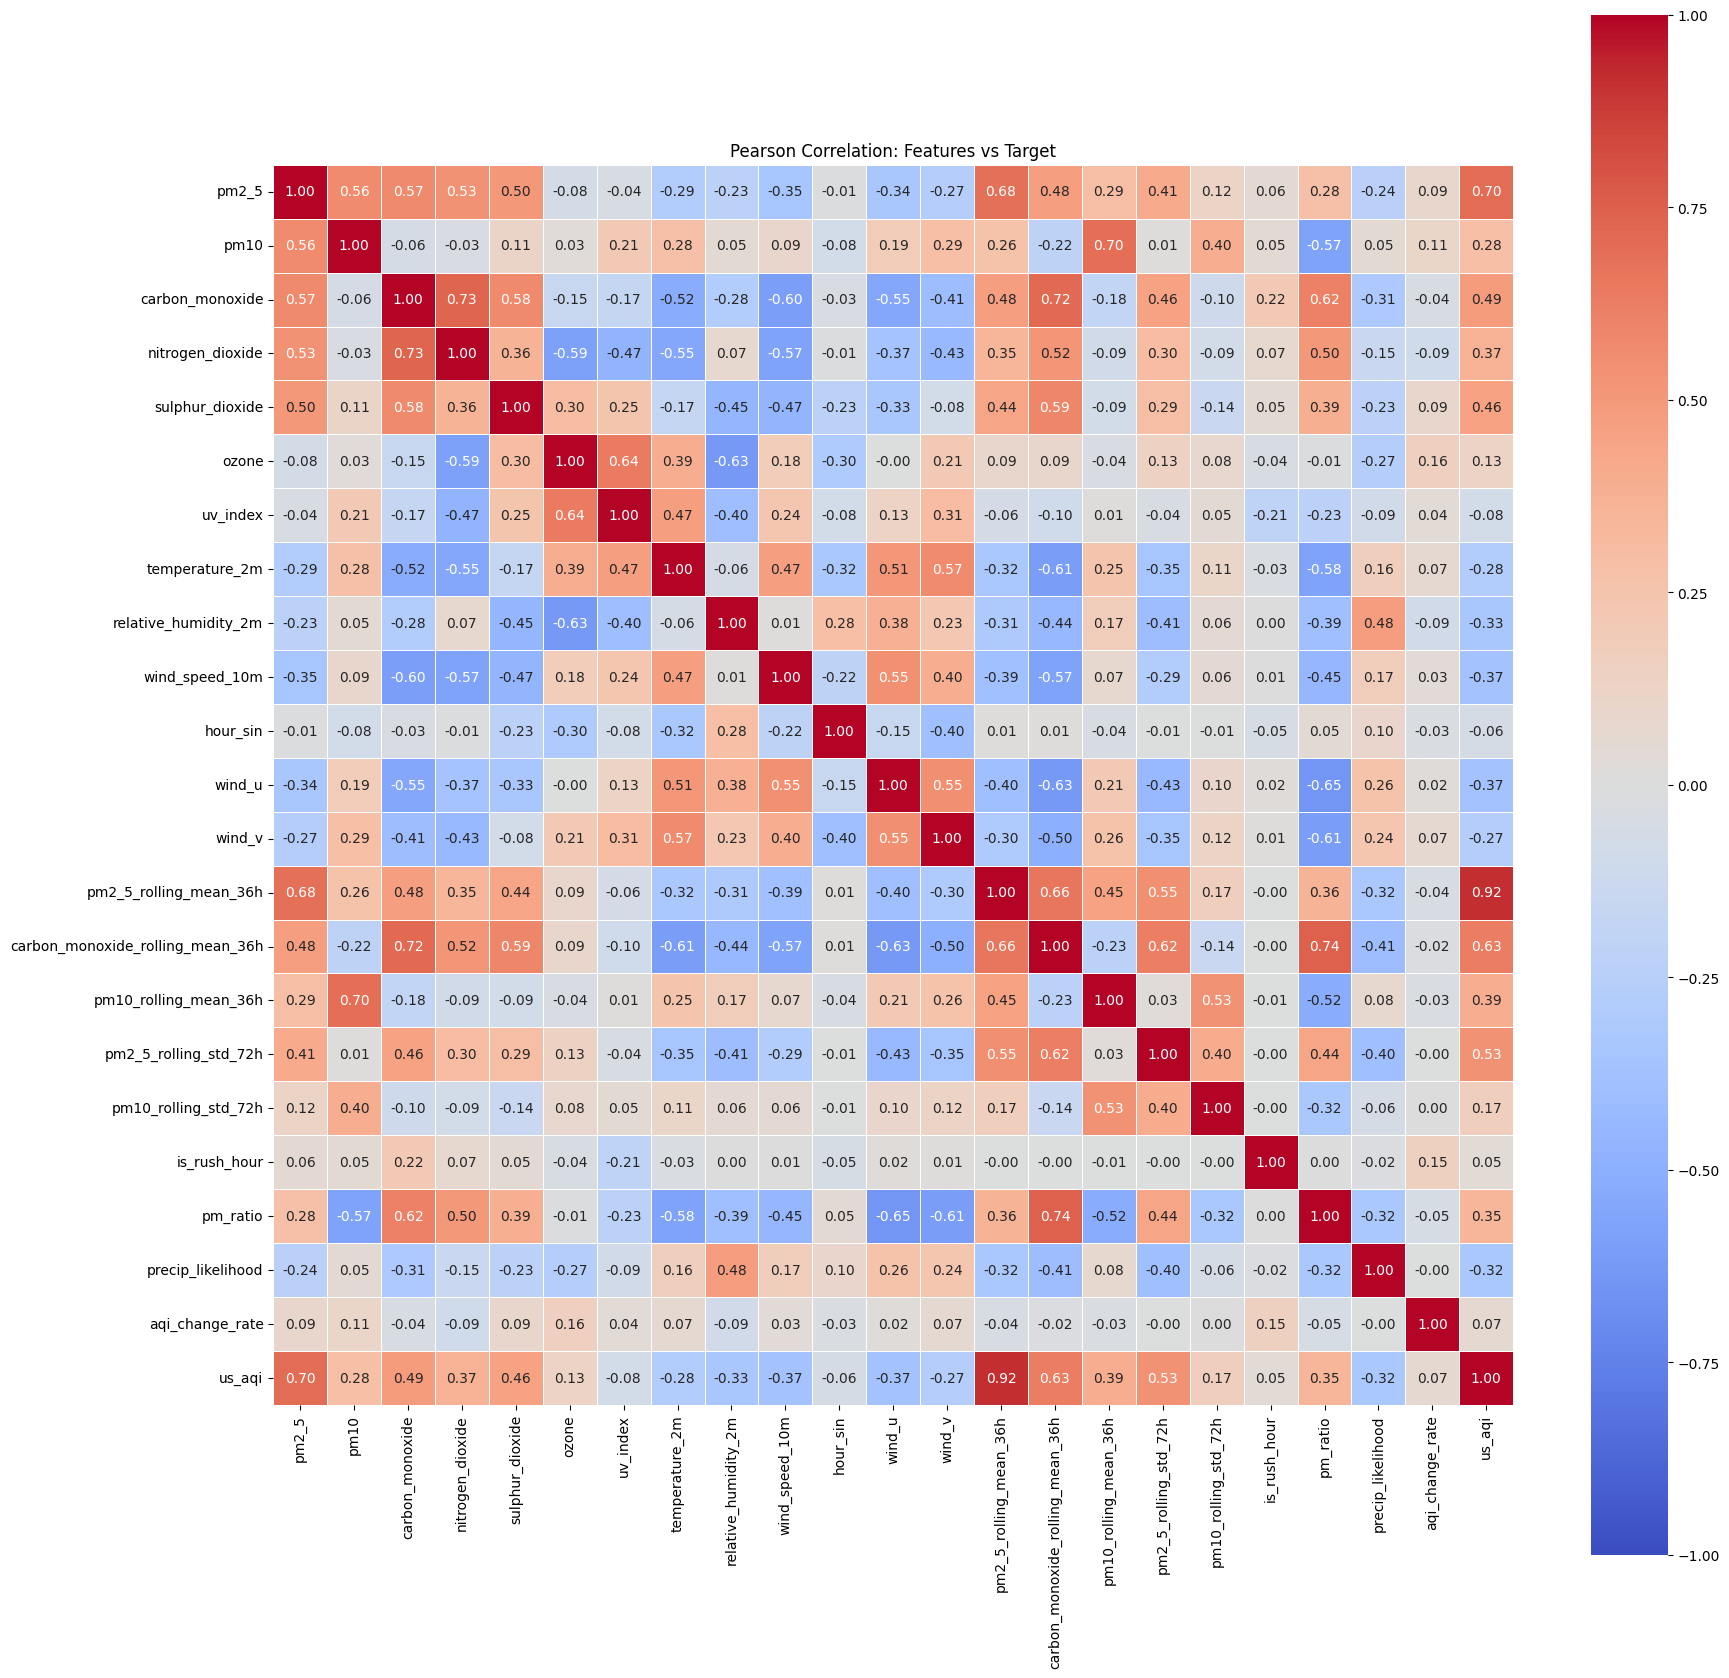

In [149]:
# select features that exist in df
cols_all = [c for c in feature_cols if c in df.columns] + [target_col]
corr_all = df[cols_all].corr(method='pearson')

# Correlation table between target and each feature
corr_target = corr_all['us_aqi']
corr_target_df = corr_target.reset_index().rename(columns={'index':'feature', 'us_aqi':'pearson_r'})
corr_target_df['abs_r'] = corr_target_df['pearson_r'].abs()
corr_target_df = corr_target_df.sort_values('abs_r', ascending=False).reset_index(drop=True)

print("Pearson correlation between target and features:")
print(corr_target_df[['feature','pearson_r']])

plt.figure(figsize=(20,20))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Pearson Correlation: Features vs Target")
plt.show()

# 5. Export Engineered Features

In [150]:
df.to_csv("engineered_features.csv", index=False)
print(f"Shape: {df.shape}")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())

Shape: (8784, 24)
Rows: 8784, Columns: 24

First few rows:
             datetime  us_aqi  pm2_5  pm10  carbon_monoxide  nitrogen_dioxide  \
0 2025-05-26 00:00:00      83   30.6  63.1            190.0              13.7   
1 2025-05-26 01:00:00      84   29.1  59.5            166.0              11.3   
2 2025-05-26 02:00:00      84   27.7  56.3            149.0               9.2   
3 2025-05-26 03:00:00      85   26.4  53.4            137.0               7.5   
4 2025-05-26 04:00:00      85   25.0  50.1            132.0               6.1   

   sulphur_dioxide  ozone  uv_index  temperature_2m  ...        wind_v  \
0             11.3   47.0       0.0            29.2  ...  1.054584e+00   
1             10.0   50.0       0.0            29.1  ...  7.170026e-01   
2              8.8   52.0       0.0            29.0  ...  2.608498e-15   
3              7.9   54.0       0.0            29.0  ... -1.892754e+00   
4              7.2   55.0       0.0            28.9  ... -4.377858e+00   

   pm2_5_